In [3]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
today = date.today()

d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=720)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

data = yf.download('AAPL', start=start_date, end=end_date, progress=False, multi_level_index=False)
print(data.head())

                 Close        High         Low        Open     Volume
Date                                                                 
2024-04-08  166.930786  167.674022  166.722689  167.505557   37425500
2024-04-09  168.139801  168.546107  166.831714  167.178548   42373800
2024-04-10  166.266846  167.565029  165.602890  167.277651   49709300
2024-04-11  173.461349  173.877575  166.643409  166.821778   91070300
2024-04-12  174.957733  176.751407  172.638841  172.688378  101670900


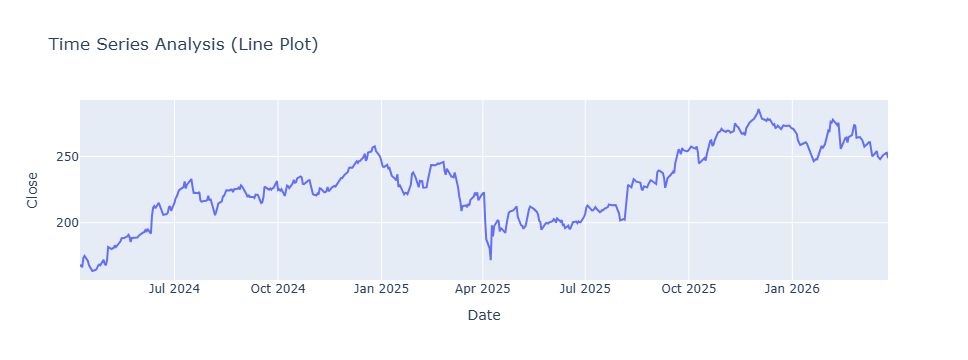

In [ ]:
import plotly.express as px

fig = px.line(
    data.reset_index(),      # make Date a normal column
    x="Date",                # use the column name, not data.index
    y="Close",
    title="Time Series Analysis (Line Plot)"
)
fig.show()

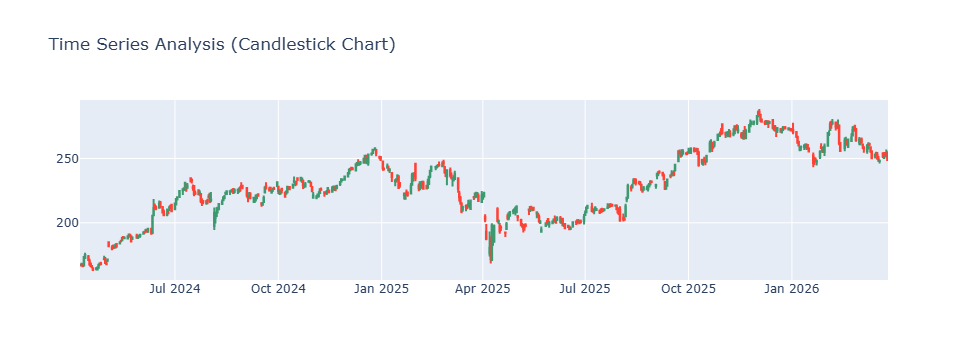

In [10]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x = data.index,
                                        open = data["Open"], 
                                        high = data["High"],
                                        low = data["Low"], 
                                        close = data["Close"])])
figure.update_layout(title = "Time Series Analysis (Candlestick Chart)", 
                     xaxis_rangeslider_visible = False)
figure.show()

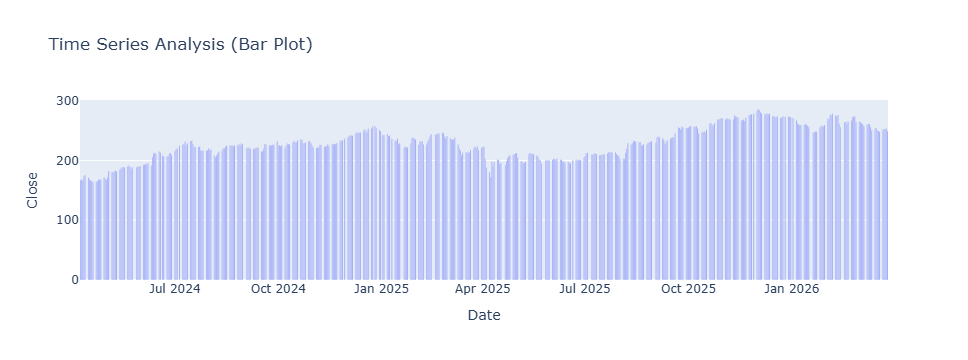

In [12]:
figure = px.bar(data, x = data.index, 
                y = "Close", 
                title = "Time Series Analysis (Bar Plot)" )
figure.show()

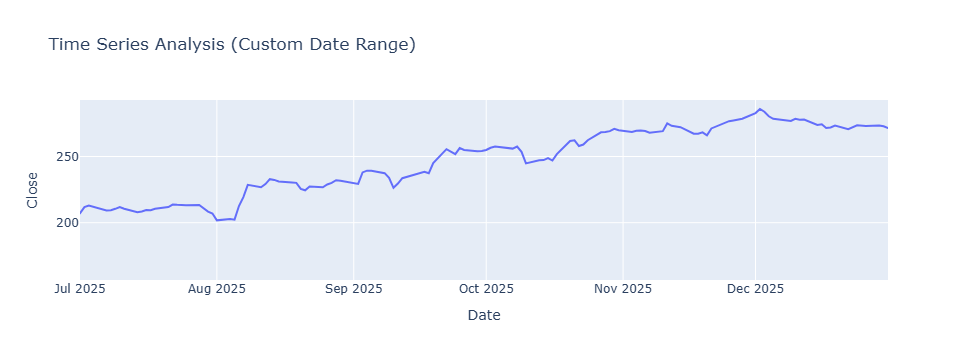

In [15]:
figure = px.line(data, x = data.index, 
                 y = 'Close', 
                 range_x = ['2025-07-01','2025-12-31'], 
                 title = "Time Series Analysis (Custom Date Range)")
figure.show()

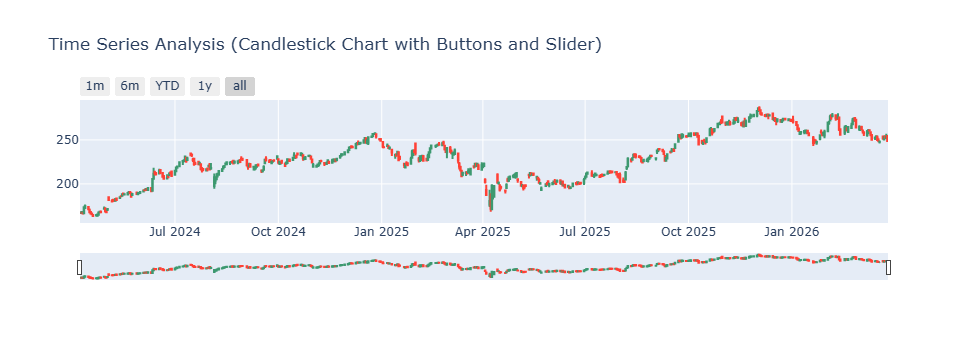

In [17]:
figure = go.Figure(data = [go.Candlestick(x = data.index,
                                        open = data["Open"], 
                                        high = data["High"],
                                        low = data["Low"], 
                                        close = data["Close"])])
figure.update_layout(title = "Time Series Analysis (Candlestick Chart with Buttons and Slider)")

figure.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict(
        buttons = list([
            dict(count = 1, label = "1m", step = "month", stepmode = "backward"),
            dict(count = 6, label = "6m", step = "month", stepmode = "backward"),
            dict(count = 1, label = "YTD", step = "year", stepmode = "todate"),
            dict(count = 1, label = "1y", step = "year", stepmode = "backward"),
            dict(step = "all")
        ])
    )
)
figure.show()